Why the hypothesis family? 

This is a *limiting* factor, which seems to stop one to achieve better accuracy / performance. However, this limitation is crucial in machine learning. It is this limit that introduces necessary "inductive biases". The "biases" allow the model to generalize beyond the training data. 

We will see an example, where without imposing any restrictions except toto adhere to the training data (perfect match!) 

We will see that this lacks the ability to predict on unseen instances. 

Lack of prior limitations leads to overfit to the data.

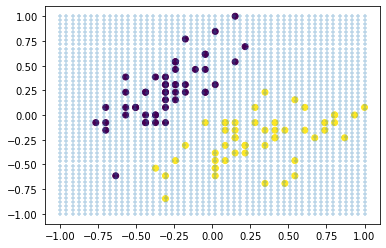

In [87]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
X, y = X[:100, :2], (y[:100]-0.5)*2

# Center and normalize each feature to [-1,1]
X = X - np.mean(X, axis=0)
X = X / np.max(np.abs(X), axis=0)

import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)

grid_num = 50
xgrid, ygrid = np.meshgrid(np.linspace(-1, 1, grid_num), np.linspace(-1, 1, grid_num))
gridsamples = np.stack([xgrid.flatten(), ygrid.flatten()]).T

plt.scatter(gridsamples[:, 0], gridsamples[:, 1], s=10, alpha=0.3, marker='+')

In [5]:
2 ** 2500

375828023454801203683362418972386504867736551759258677056523839782231681498337708535732725752658844333702457749526057760309227891351617765651907310968780236464694043316236562146724416478591131832593729111221580180531749232777515579969899075142213969117994877343802049421624954402214529390781647563339535024772584901607666862982567918622849636160208877365834950163790188523026247440507390382032188892386109905869706753143243921198482212075444022433366554786856559389689585638126582377224037721702239991441466026185752651502936472280911018500320375496336749951569521541850441747925844066295279671872605285792552660130702047998218334749356321677469529682551765858267502715894007887727250070780350262952377214028842297486263597879792176338220932619489509376

In [6]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
X, y = X[:100, :2], (y[:100]-0.5)*2

# Center and normalize each feature to [-1,1]
X = X - np.mean(X, axis=0)
X = X / np.max(np.abs(X), axis=0)

grid_num = 50
xgrid, ygrid = np.meshgrid(np.linspace(-1, 1, grid_num), np.linspace(-1, 1, grid_num))
gridsamples = np.stack([xgrid.flatten(), ygrid.flatten()]).T

def fit_train(gridsamples, X, y, d=0.023):
    constraints = {}

    for i, xi in enumerate(X):
        dist = np.linalg.norm(gridsamples - xi, axis=1)
        idxs = np.where(dist < d)[0]
        for idx in idxs:
            constraints[idx] = [gridsamples[idx, 0], gridsamples[idx, 1], y[i]]
    return constraints

def get_h(gridsamples, constraints, rng=None):
    if rng is None:
        rng = np.random.RandomState(42)
    gridlabels = []
    for i in range(len(gridsamples)):
        if i in constraints:
            gridlabels.append(constraints[i][-1])
        else:
            gridlabels.append(rng.choice([-1, 1]))
    return gridlabels

rng = np.random.RandomState(42)
constraints = fit_train(gridsamples, X, y)

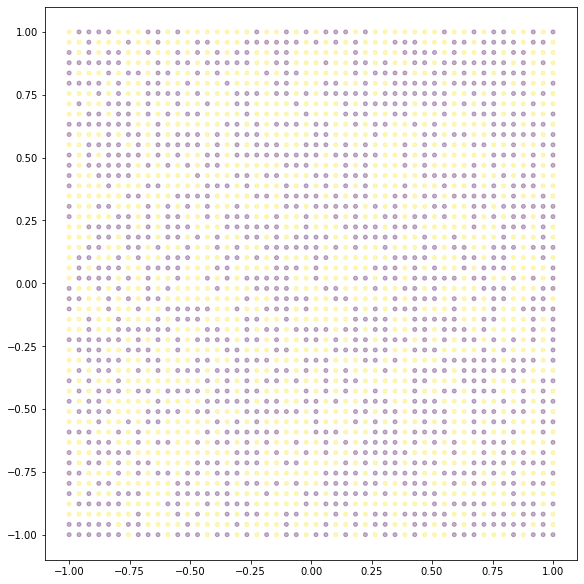

In [16]:
import matplotlib.pyplot as plt

fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8,8))
# ax2.scatter(X[:, 0], X[:, 1], c=y, s=100, marker='s', alpha=0.5)

constraints = {}
gridlabels = get_h(gridsamples, constraints, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)
if len(constraints_disp)>0:
    ax2.scatter(constraints_disp[:, 0], constraints_disp[:, 1], c=constraints_disp[:, 2], s=100, marker='+')

In [48]:
# How may possiblilies?
n0 = 2 ** len(gridsamples)
print(n0)

375828023454801203683362418972386504867736551759258677056523839782231681498337708535732725752658844333702457749526057760309227891351617765651907310968780236464694043316236562146724416478591131832593729111221580180531749232777515579969899075142213969117994877343802049421624954402214529390781647563339535024772584901607666862982567918622849636160208877365834950163790188523026247440507390382032188892386109905869706753143243921198482212075444022433366554786856559389689585638126582377224037721702239991441466026185752651502936472280911018500320375496336749951569521541850441747925844066295279671872605285792552660130702047998218334749356321677469529682551765858267502715894007887727250070780350262952377214028842297486263597879792176338220932619489509376


Fit 1587 gridsamples


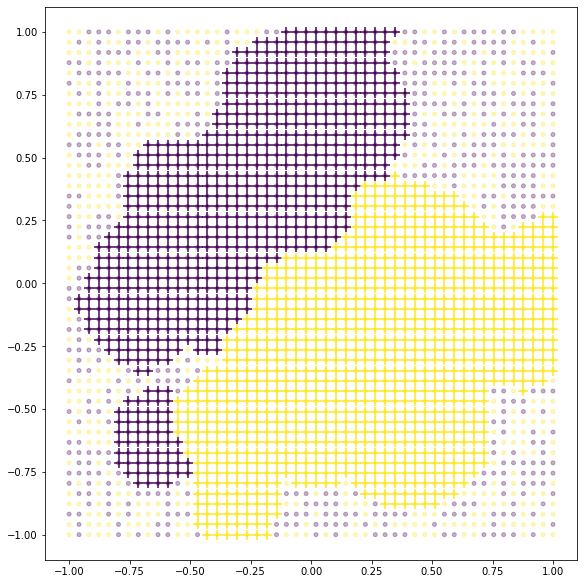

In [33]:
fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(8, 8))
#constraints = fit_train(gridsamples, X, y, d=0.025)
constraints = fit_train(gridsamples, X, y, d=0.2)
print(f"Fit {len(constraints)} gridsamples")
gridlabels = get_h(gridsamples, constraints, rng)
constraints_disp = np.array([v for k, v in constraints.items()])
ax2.scatter(gridsamples[:, 0], gridsamples[:, 1], c=gridlabels, s=16, alpha=0.3)
if len(constraints_disp)>0:
    ax2.scatter(constraints_disp[:, 0], constraints_disp[:, 1], c=constraints_disp[:, 2], s=100, marker='+')

In [18]:
print(constraints)

{1618: [-0.26530612244897966, 0.30612244897959173, -1.0], 1619: [-0.22448979591836737, 0.30612244897959173, -1.0], 1165: [-0.3877551020408164, -0.061224489795918435, -1.0], 1312: [-0.5102040816326531, 0.06122448979591821, -1.0], 1717: [-0.30612244897959184, 0.3877551020408163, -1.0], 2023: [-0.061224489795918435, 0.6326530612244896, -1.0], 1510: [-0.5918367346938775, 0.22448979591836715, -1.0], 1511: [-0.5510204081632654, 0.22448979591836715, -1.0], 1517: [-0.30612244897959184, 0.22448979591836715, -1.0], 1057: [-0.7142857142857143, -0.1428571428571429, -1.0], 1265: [-0.3877551020408164, 0.020408163265306145, -1.0], 1823: [-0.061224489795918435, 0.46938775510204067, -1.0], 1514: [-0.4285714285714286, 0.22448979591836715, -1.0], 1164: [-0.4285714285714286, -0.061224489795918435, -1.0], 1156: [-0.7551020408163265, -0.061224489795918435, -1.0], 2080: [0.22448979591836715, 0.6734693877551019, -1.0], 2130: [0.22448979591836715, 0.7142857142857142, -1.0], 2478: [0.1428571428571428, 1.0, -1.0

In [34]:
n1 = 2**(len(gridsamples) - len(constraints))


print(f"The possible solutions is now 1/{2**len(constraints)}")

print(f"Now there are only \n", n1, "\npossibilities")

The possible solutions is now 1/5427541073864019118654396248232100136208402650407451088796169811249228890352679716672947091818111501157953310686163254851697638727451657631394655359083594985298167123855031247159509972942515507694815766757212381257984081550954366900962528782824476805618535440581890907474350239455870045395236765001476688194636417480702552657087703728289659693114976053255092930944362823388998381429420740456367769166254919481157451577384766652401583879945303863133330878849972040685566482710528
Now there are only 
 69244620785013915169893880288577664649638356718206520148356066053544201755915040781030818563707002931730762300556198370198467059319135998738502644985094416224536059445117594392163977484884566481701992255745056886508490364387532700233026358315193005046436800875428314917896192 
possibilities
